# A/B Test Analysis

This notebook evaluates whether the treatment variant produced better user outcomes than the control variant using descriptive statistics, visualization, and hypothesis testing.

## 1. Research Question and Hypotheses

**Research question:** Does the treatment version improve user engagement and conversion outcomes compared with the control version?

### Primary metric
- **Completion rate** (`completed`)

### Secondary metrics
- **Click rate** (`click`)
- **Time spent** (`time_spent`)
- **Page views** (`page_views`)
- **Steps reached** (`steps_reached`)
- **Bounce rate** (`bounce`)

### Hypotheses
For each metric, the null hypothesis states that there is no difference between Group A and Group B.  
The alternative hypothesis states that there is a difference between the two groups.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

## 2. Load Data

In [2]:
df = pd.read_csv("ab_analysis_dataset.csv")
df.head()

,user_id,group,click,completed,time_spent,page_views,steps_reached,bounce
0,1,A,0,0,27.72,2,2,0
1,2,B,0,1,117.27,7,5,0
2,3,A,1,1,109.39,5,5,0
3,4,A,0,0,23.79,5,3,0
4,5,A,1,1,111.86,4,5,0


## 3. Data Overview and Quality Checks

In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_count"))

print("\nGroup sizes:")
display(df["group"].value_counts().rename_axis("group").to_frame("n"))

Shape: (5000, 8)

Columns:
['user_id', 'group', 'click', 'completed', 'time_spent', 'page_views', 'steps_reached', 'bounce']

Missing values:


,missing_count
user_id,0
group,0
click,0
completed,0
time_spent,0
page_views,0
steps_reached,0
bounce,0



Group sizes:


,n
group,
A,2504
B,2496


In [4]:
numeric_summary = df.groupby("group")[["click", "completed", "time_spent", "page_views", "steps_reached", "bounce"]].agg(["mean", "std"])
numeric_summary

click           completed           time_spent             \
           mean       std      mean       std       mean        std   
group                                                                 
A      0.686102  0.464168  0.660144  0.473755  79.900954  41.319908   
B      0.541667  0.498361  0.405048  0.491000  70.163750  48.359517   

      page_views           steps_reached              bounce            
            mean       std          mean       std      mean       std  
group                                                                   
A       4.389776  2.289616      4.662939  1.327589  0.031550  0.174832  
B       2.937099  1.886257      2.985978  1.415985  0.003205  0.056534

The dataset is balanced across groups and contains no missing values, which supports a clean comparison between variants.

## 4. Exploratory Data Analysis

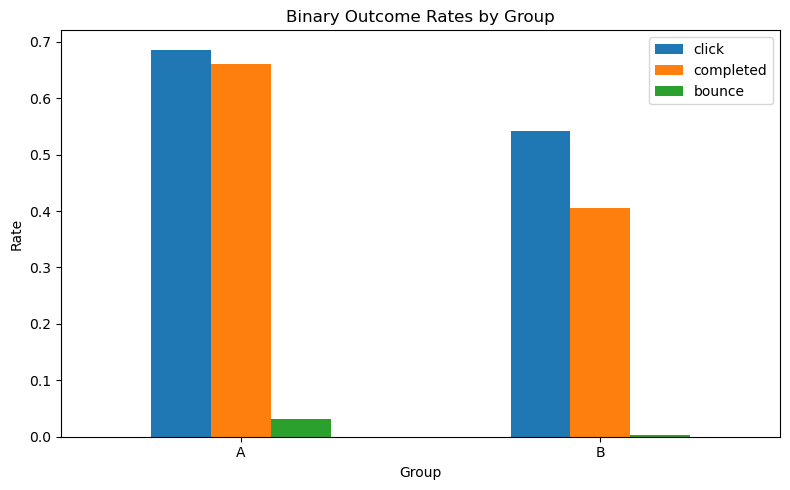

In [5]:
group_means = df.groupby("group")[["click", "completed", "bounce"]].mean()

ax = group_means.plot(kind="bar", figsize=(8, 5))
ax.set_title("Binary Outcome Rates by Group")
ax.set_ylabel("Rate")
ax.set_xlabel("Group")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

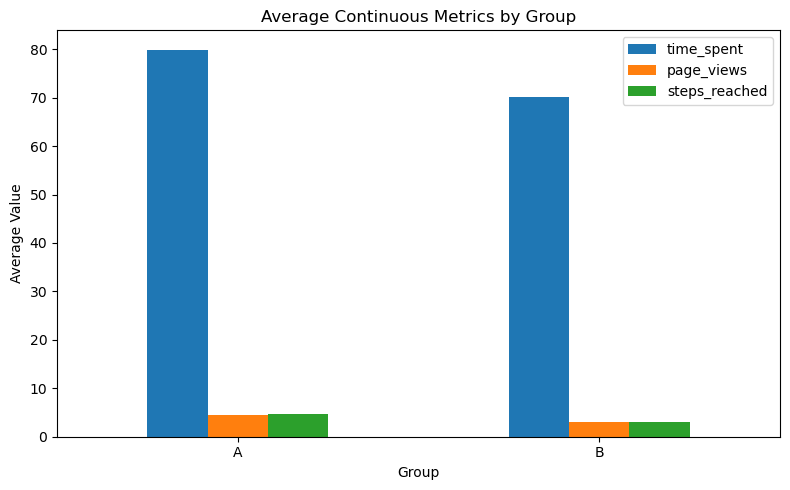

In [6]:
continuous_means = df.groupby("group")[["time_spent", "page_views", "steps_reached"]].mean()

ax = continuous_means.plot(kind="bar", figsize=(8, 5))
ax.set_title("Average Continuous Metrics by Group")
ax.set_ylabel("Average Value")
ax.set_xlabel("Group")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

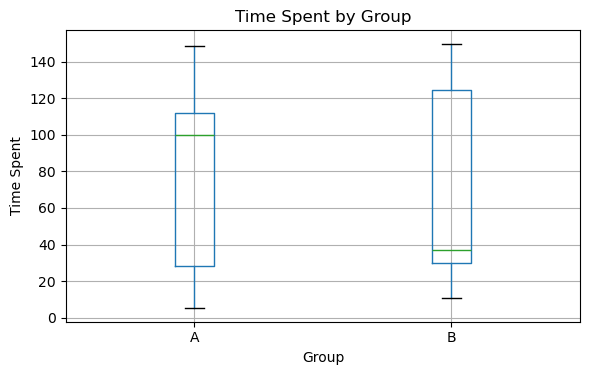

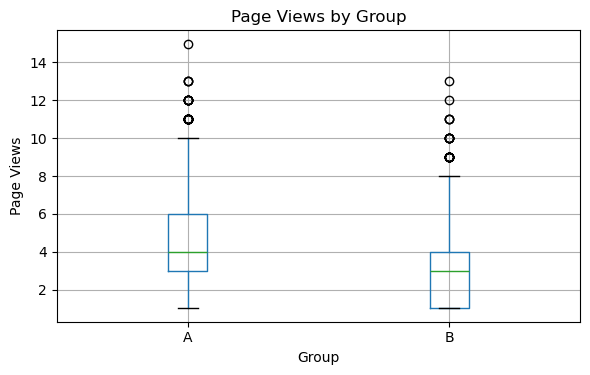

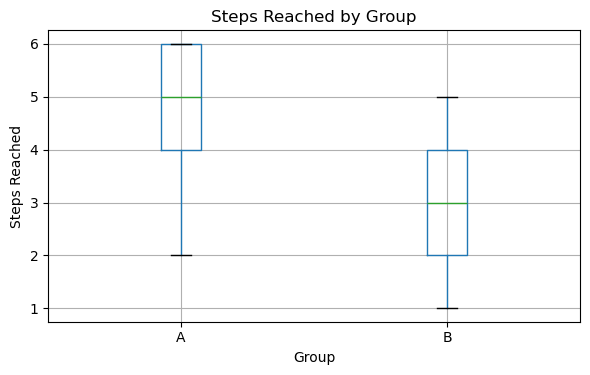

In [7]:
for metric in ["time_spent", "page_views", "steps_reached"]:
    df.boxplot(column=metric, by="group", figsize=(6, 4))
    plt.title(f"{metric.replace('_', ' ').title()} by Group")
    plt.suptitle("")
    plt.xlabel("Group")
    plt.ylabel(metric.replace("_", " ").title())
    plt.tight_layout()
    plt.show()

The visual patterns already suggest that Group A outperforms Group B on most engagement and conversion measures. Formal hypothesis tests are used next to determine whether these differences are statistically significant.

## 5. Statistical Testing

### 5.1 Proportion z-tests for binary metrics

For binary outcomes such as click, completion, and bounce, a two-sample proportion z-test is appropriate because the goal is to compare event rates between two independent groups.

In [8]:
def proportion_test(data, metric):
    a = data.loc[data["group"] == "A", metric]
    b = data.loc[data["group"] == "B", metric]

    count = np.array([a.sum(), b.sum()])
    nobs = np.array([len(a), len(b)])

    z_stat, p_value = proportions_ztest(count, nobs)
    ci_low, ci_high = confint_proportions_2indep(
        b.sum(), len(b), a.sum(), len(a), method="wald"
    )

    return {
        "metric": metric,
        "A_rate": a.mean(),
        "B_rate": b.mean(),
        "B_minus_A": b.mean() - a.mean(),
        "z_stat": z_stat,
        "p_value": p_value,
        "95%_CI_low": ci_low,
        "95%_CI_high": ci_high
    }

binary_results = pd.DataFrame([
    proportion_test(df, "click"),
    proportion_test(df, "completed"),
    proportion_test(df, "bounce")
])

binary_results

,metric,A_rate,B_rate,B_minus_A,z_stat,p_value,95%_CI_low,95%_CI_high
0,click,0.686102,0.541667,-0.144436,10.489403,9.663704e-26,-0.171128,-0.117743
1,completed,0.660144,0.405048,-0.255096,18.076904,4.845348e-73,-0.281837,-0.228355
2,bounce,0.031550,0.003205,-0.028344,7.664055,1.801530e-14,-0.035541,-0.021148


### 5.2 Welch's t-tests for continuous metrics

For continuous outcomes, Welch's t-test is used because it compares means between two independent groups without assuming equal variances.

In [9]:
def welch_t_test(data, metric):
    a = data.loc[data["group"] == "A", metric]
    b = data.loc[data["group"] == "B", metric]

    t_stat, p_value = stats.ttest_ind(a, b, equal_var=False)

    mean_diff = b.mean() - a.mean()
    se = np.sqrt((a.var(ddof=1) / len(a)) + (b.var(ddof=1) / len(b)))
    ci_low = mean_diff - 1.96 * se
    ci_high = mean_diff + 1.96 * se

    pooled_sd = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2))
    cohens_d = mean_diff / pooled_sd

    return {
        "metric": metric,
        "A_mean": a.mean(),
        "B_mean": b.mean(),
        "B_minus_A": mean_diff,
        "t_stat": t_stat,
        "p_value": p_value,
        "95%_CI_low": ci_low,
        "95%_CI_high": ci_high,
        "cohens_d": cohens_d
    }

continuous_results = pd.DataFrame([
    welch_t_test(df, "time_spent"),
    welch_t_test(df, "page_views"),
    welch_t_test(df, "steps_reached")
])

continuous_results

,metric,A_mean,B_mean,B_minus_A,t_stat,p_value,95%_CI_low,95%_CI_high,cohens_d
0,time_spent,79.900954,70.163750,-9.737204,7.653107,2.349809e-14,-12.230952,-7.243456,-0.216517
1,page_views,4.389776,2.937099,-1.452677,24.488158,6.259776e-125,-1.568947,-1.336407,-0.692418
2,steps_reached,4.662939,2.985978,-1.676962,43.195967,0.000000e+00,-1.753053,-1.600870,-1.221894


## 6. Summary Table

In [10]:
summary_table = pd.concat([
    binary_results[["metric", "A_rate", "B_rate", "B_minus_A", "p_value"]],
    continuous_results[["metric", "A_mean", "B_mean", "B_minus_A", "p_value"]]
], axis=0, ignore_index=True)

summary_table

,metric,A_rate,B_rate,B_minus_A,p_value,A_mean,B_mean
0,click,0.686102,0.541667,-0.144436,9.663704e-26,NaN,NaN
1,completed,0.660144,0.405048,-0.255096,4.845348e-73,NaN,NaN
2,bounce,0.031550,0.003205,-0.028344,1.801530e-14,NaN,NaN
3,time_spent,NaN,NaN,-9.737204,2.349809e-14,79.900954,70.163750
4,page_views,NaN,NaN,-1.452677,6.259776e-125,4.389776,2.937099
5,steps_reached,NaN,NaN,-1.676962,0.000000e+00,4.662939,2.985978


## 7. Interpretation

Key findings from the analysis:

- **Completion rate:** Group B performs substantially worse than Group A, and the difference is statistically significant.
- **Click rate:** Group B also has a significantly lower click rate.
- **Bounce rate:** Group B has a significantly lower bounce rate, which is favorable, but this improvement does not offset the much weaker conversion and engagement outcomes.
- **Time spent, page views, and steps reached:** Group A shows significantly stronger engagement across all three metrics.

Overall, the treatment version does **not** outperform the control version on the primary business goal of completion. Based on these results, **Group A should be preferred over Group B** under the current design.

## 8. Limitations

- The analysis is based on the provided dataset only; conclusions depend on the quality and realism of the underlying data collection process.
- Statistical significance does not automatically imply business significance, so practical impact should also be considered.
- Additional segmentation analysis could reveal whether treatment performance differs across user subgroups.

## 9. Conclusion

This A/B test provides strong statistical evidence that the treatment variant underperforms the control on the primary metric and several important engagement metrics. The current evidence does not support deploying Group B as a replacement for Group A.